In [7]:
## John Gallagher
## AVF: implementation of double pendulum
## June 11, 2026

Given a Hamiltonian system with a Hamiltonian function $H:\mathbb{R}^{2d}\rightarrow \mathbb{R}$,

$$
\begin{align*}
\dot{\boldsymbol x}(t) &= J\nabla H(\boldsymbol x(t)),\\
\boldsymbol x(0) &= \boldsymbol x_0
\end{align*}
$$

The following scheme is called the Average Vector Field [[QM08](#ref-qm08)] discrete gradient scheme to exactly preserve the Hamiltonian:

$$
\begin{align*}
\boldsymbol x_{n+1} &= \boldsymbol x_n + \tau_n J\,\overline{\nabla H}(\boldsymbol x_{n+1},\boldsymbol x_n), \quad\text{where} \tag{1}\\
\overline{\nabla H}(\boldsymbol x_{n+1},\boldsymbol x_n) &= \int_0^1 \nabla H\big(\boldsymbol x_n + s(\boldsymbol x_{n+1}-\boldsymbol x_n)\big)\,ds.
\end{align*}
$$

$\overline{\nabla H}(\boldsymbol x_{n+1},\boldsymbol x_n)$ is a particular example of a *discrete gradient* (there are other choices also), which satisfies the property

$$
\overline{\nabla H}(\boldsymbol y,\boldsymbol x)^T(\boldsymbol y-\boldsymbol x) = H(\boldsymbol y)-H(\boldsymbol x), \quad\text{for all } \boldsymbol x,\boldsymbol y\in\mathbb{R}^{2d}.
$$

It follows from this property that the solutions of (1) preserve energy since

$$
\begin{align*}
H(\boldsymbol x_{n+1})-H(\boldsymbol x_n)
&= \overline{\nabla H}(\boldsymbol x_{n+1},\boldsymbol x_n)^T(\boldsymbol x_{n+1}-\boldsymbol x_n) \\
&= \tau_n\, \overline{\nabla H}(\boldsymbol x_{n+1},\boldsymbol x_n)^T J\,\overline{\nabla H}(\boldsymbol x_{n+1},\boldsymbol x_n) = 0,
\end{align*}
$$

where the last equality follows from the skew-symmetric property of $J$. Note that it is also shown in [[MW26](#ref-mw26)] that the AVF scheme is also $R$-reversible, which is needed to show stationarity.

In practice, to write out the AVF scheme (1), one can either evaluate the integral analytically (doable mainly for polynomial Hamiltonians like the Gaussian) or approximate it using numerical quadratures (typically Gauss-Legendre quadrature).

---

## References

<a name="ref-qm08"></a>
**[QM08]** Quispel, G. R. W. and McLaren, D. I., "A new class of energy-preserving numerical integration methods," *J. Phys. A: Math. Theor.*, vol. 41, no. 4, p. 045206, 2008.

<a name="ref-mw26"></a>
**[MW26]** McGregor, G. and Wan, A. T. S., "Improving sampling efficacy on high-dimensional distributions with thin high-density regions using Conservative Hamiltonian Monte Carlo," *PNAS Nexus*, vol. 5, no. 6, p. pgag178, 2026. https://doi.org/10.1093/pnasnexus/pgag178


In [10]:
## Double Pendulum in jax using FPI
## For verification of AVF
## 

import jax
jax.config.update("jax_enable_x64", True)
from jax import vmap, jit, grad
import jax.numpy as jnp
from typing import NamedTuple, Callable
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.special import roots_legendre
from scipy.integrate import fixed_quad, quad_vec


### Temporary parameters
m0, m1 = 1, 1
m = m1/(m0+m1)
l0, l1 = 1, 1
g = 9.81

#Useful Classes I've developed
class QP(NamedTuple):
    """Phase space state(q,p)"""
    q: jnp.ndarray # position
    p: jnp.ndarray # momentum

    @property
    def dim(self) -> int:
        """Dimension of configuration space"""
        return self.q.shape[0]
    def to_array(self) -> jnp.ndarray:
        """Convert to flat array [q,p] for compatability with old code"""
        return jnp.concatenate([self.q, self.p])
    @classmethod
    def from_array(cls, arr: jnp.ndarray):
        """Convert from flat array[q,p]"""
        dim = arr.shape[0]//2
        return cls(q=arr[:dim], p=arr[dim:])

class IntegratorConfig (NamedTuple):
    """Configuration for numerical integrators"""
    τ: float # time-step size
    T: float # final time T = N*τ
    N: int # Number of integration steps = int(ceil(T/τ))
    tol: float = 1e-2 # Tolerance of implicit method
    max_iter: int = 3 # Max Newton iter
    n_pts: int = 4

class IntegratorState(NamedTuple):
    """State during FPI Newton iteration"""
    qp: QP
    residual: QP # F(qp) tolerance
    step_size: float # adaptive step size during integration
    n_iter: int
    converged: bool
    residual_norm: float
# Symplectic operations
def J_sym(qp: QP) -> QP:
    """
    J is the symplectic Jacobian matrix for Hamiltonians where 
    J = ([[0, I], [-I, 0]])
    """
    return QP(q = qp.p, p = -qp.q)
def J_sym_flat(vec) -> jnp.array:
    """
    J is the symplectic Jacobian matrix for Hamiltonians where 
    J = ([[0, I], [-I, 0]])
    """
    qp = QP.from_array(vec)
    outvec = QP(q = qp.p, p = -qp.q).to_array()
    return outvec


Derived by hand and checked from resource below. 
Equations of motion: notation and excerpt is from: https://dassencio.org/33


In [11]:
def α0(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return l1/l0*m*jnp.cos(θ0- θ1)

def α1(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return l0/l1*jnp.cos(θ0- θ1)

def f0(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return -l1/l0 * m * ω1**2*jnp.sin(θ0-θ1)-g/l0 *jnp.sin(θ0)

def f1(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return l0/l1 * ω0**2*jnp.sin(θ0-θ1)-g/l1 *jnp.sin(θ1)

def detA(qp):
    return 1-α0(qp)*α1(qp)
def Ainv(qp):
    return 1/detA(qp)*jnp.array([[1, -α0(qp)],[-α1(qp), 1]])

def ddθ(qp):
    return Ainv(qp)@jnp.array([f0(qp), f1(qp)])

In [ ]:


def gen_Energy(m0=1., m1=1., l0=1., l1=1., g=9.81, flat=False):
    def M_matrix(θ0, θ1):
        """True mass matrix from ∂²L/∂θ̇²"""
        return jnp.array([
            [(m0+m1)*l0**2, m1*l0*l1*jnp.cos(θ0-θ1)],
            [m1*l0*l1*jnp.cos(θ0-θ1), m1*l1**2]
        ])
    
    def K(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p  # canonical momenta
        M_inv = jnp.linalg.inv(M_matrix(θ0, θ1))
        P = jnp.array([P0, P1])
        return 0.5 * P @ M_inv @ P

    def V(qp):
        θ0,θ1 = qp.q
        ω0,ω1 = qp.p
        V0 = (m0+m1)*g*l0*jnp.cos(θ0) 
        V1 = m1*g*l1*jnp.cos(θ1) 
        return -V0 - V1
    if flat: 
        def Hamiltonian(vec):
            qp = QP.from_array(vec)
            return K(qp)+V(qp)
    else:
        def Hamiltonian(qp):
            return K(qp)+V(qp)
        return Hamiltonian
def gauss(config,
           a=0.,
           b=1.
           ):
    """
    Generate the rescaled gauss quadrature points
    """
    β1 = (b-a)/2
    β0= (a+b)/2
    roots, weights = roots_legendre(config.n_pts)

    Xout = β1*roots+β0
    Wout = β1*weights
    return Xout, Wout

def gen_AVF(gradH, config):
    ti, wi = gauss(config, 0,1)
    def AVF(qp0: QP,
            qp1: QP,
            ):
        """Implementing AVF 
        qp_{n+1} = qp_n + τ * J vmap(∇H)((qp_n + qp_{n+1}))

        This is numerical implementation but i'll likely need to do some more solving for gradH_flat
        """
        x0 = qp0.to_array()
        X0 = jnp.expand_dims(x0, -1)
        X1 = jnp.expand_dims(qp1.to_array(), -1)
        X = X0+ ti*(X1-X0)
        vgradH = vmap(gradH, in_axes=-1)
        x_out = x0 + config.τ* J_sym_flat(wi@ vgradH(X))
        return QP.from_array(x_out)
    return AVF
def gen_FPI(func, config):
    def FPI(carry, xs):
        xn = carry
        xn1 = func(xn, xn)
        def cond(carry):
            """bool for while err> tol and iter< max_iter"""
            i, x, y = carry
            residual_q = y.q - x.q
            residual_p = y.p - x.p

            err = jnp.sqrt(
                jnp.sum(residual_q**2) +
                jnp.sum(residual_p**2))
            return (err > config.tol) & (i< config.max_iter)
        def body_step(carry):
            i, x, y = carry
            return (i +1, y, func(xn, y))
        n_iter, _, x_next = jax.lax.while_loop(cond, body_step, (1, xn, xn1))
        return x_next, x_next
    return FPI

def gen_AVF_FPI_T(F_flat, config):
    AVF_FPI = gen_FPI(gen_AVF(F_flat, config), config)
    def AVF_FPI_T(θω_init):
        final_state, trajectory = jax.lax.scan(
            AVF_FPI,
            θω_init,
            None,
            length=config.N,
        )
        return trajectory
    return AVF_FPI_T

In [13]:
def M_matrix(θ0, θ1):
        """True mass matrix from ∂²L/∂θ̇²"""
        return jnp.array([
            [(m0+m1)*l0**2, m1*l0*l1*jnp.cos(θ0-θ1)],
            [m1*l0*l1*jnp.cos(θ0-θ1), m1*l1**2]
        ])
def M_inv(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p 
        det = (m0+m1*jnp.sin(θ0 - θ1)**2)
        return 1/det * jnp.array([[1/(l0**2),-jnp.cos(θ0 - θ1)/(l0*l1)],
                [-jnp.cos(θ0-θ1)/(l0*l1), (m0+m1)/(m1*l1**2)]])

In [14]:
H = gen_Energy()
def H_flat(qp_flat):
    return H(QP.from_array(qp_flat))
gradH = grad(H_flat)

In [15]:
m0, m1 = 1., 1.
m = m1/(m0+m1)
l0, l1 = 1., 1.
g = 9.81
t0 = 0.0
T = 20.0
dt = 0.0001
ts = jnp.arange(t0,T, dt)
N = len(ts)

dt = ts[1]-ts[0]

config = IntegratorConfig(τ=dt, T=T, N = N, tol = 1e-17, max_iter=10000, n_pts=6)

θω_init = QP.from_array(jnp.array([0.25*jnp.pi, -0.25*jnp.pi, -.2, 0.5]))

In [16]:
x0 = θω_init.to_array()
x1 = θω_init.to_array()
I = np.zeros(shape=(4,2))
for i in range(len(x0)):
    def integrand(t):
        return gradH(x0 + t*(x1-x0))[i]
    I[i] = fixed_quad(integrand, 0, 1, n=4)

ti, wi = gauss(config, 0, 1)
X0 = jnp.expand_dims(x0, -1)
X1 = jnp.expand_dims(x1, -1)
X = X0 + ti * (X1 - X0)
vgradH = vmap(gradH, in_axes=-1)
avf_result = wi @ vgradH(X)

print(f'AVF : {avf_result}')
def integrand_v(t):
    return gradH(x0 + t*(x1-x0))
quad_result, err = quad_vec(integrand_v, 0,1)
print(f'quad: {quad_result}\n quad_err_est:{err}')
print(f'diff: {avf_result-quad_result}, \ndiff_norm: {jnp.linalg.norm(avf_result-quad_result)}')

AVF : [13.82343505 -6.88671752 -0.1         0.5       ]
quad: [13.82343505 -6.88671752 -0.1         0.5       ]
 quad_err_est:5.146656880115736e-13
diff: [-1.77635684e-15 -8.88178420e-16 -1.38777878e-17  0.00000000e+00], 
diff_norm: 1.9860758090011314e-15


In [17]:
def gen_H2(m0=1., m1=1., l0=1., l1=1., g=9.81, flat=False):
    def M_inv(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p 
        det = (m0+m1*jnp.sin(θ0 - θ1)**2)
        return 1/det * jnp.array([[1/(l0**2),-jnp.cos(θ0 - θ1)/(l0*l1)],
                [-jnp.cos(θ0-θ1)/(l0*l1), (m0+m1)/(m1*l1**2)]])
    def H2(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p 
        K=0.5* qp.p@M_inv(qp)@qp.p
        U = -(m0+m1)*g*l0*jnp.cos(θ0)-m1*g*l1*jnp.cos(θ1)
        return K+U
    return H2

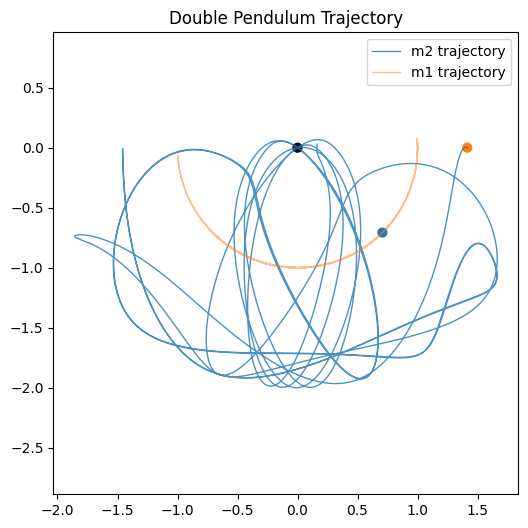

In [18]:
θω_init = QP.from_array(jnp.array([0.25*jnp.pi, -1.25*jnp.pi, -.2, 0.5]))
H = gen_Energy()
def H_flat(qp_flat):
    return H(QP.from_array(qp_flat))
gradH = grad(H_flat)


AVF_FPI_T = gen_AVF_FPI_T(gradH, config)
trajectory = AVF_FPI_T(θω_init)

x0s = l0*vmap(jnp.sin)(trajectory.q[:,0])
x1s = x0s + l1*vmap(jnp.sin)(trajectory.q[:,1])
y0s = -l0*vmap(jnp.cos)(trajectory.q[:,0])
y1s = y0s-l1*vmap(jnp.cos)(trajectory.q[:,1])

x1s_np = jnp.asarray(x1s)
y1s_np = jnp.asarray(y1s)

x0s_np = jnp.asarray(x0s)
y0s_np = jnp.asarray(y0s)

plt.figure(figsize=(6, 6))

# full trajectory of second mass (most informative)
plt.plot(x1s, y1s, lw=1, alpha=0.8, label="m2 trajectory")

# optional: trajectory of first mass
plt.plot(x0s, y0s, lw=1, alpha=0.5, label="m1 trajectory")

# starting configuration marker
plt.scatter([0, x0s[0], x1s[0]],
            [0, y0s[0], y1s[0]],
            c=["k", "C0", "C1"], s=40)

plt.axis("equal")
plt.legend()
plt.title("Double Pendulum Trajectory")
plt.show()

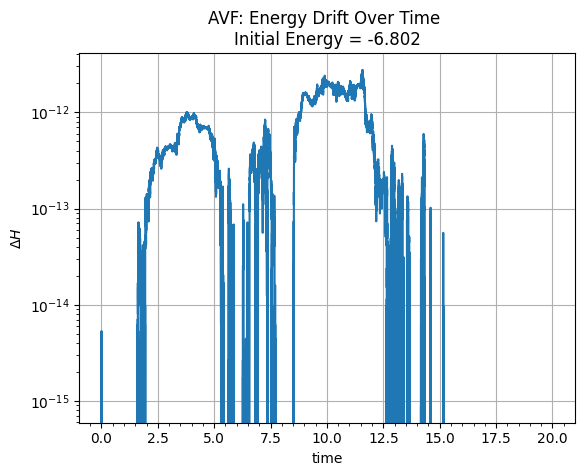

In [19]:
plt.semilogy(ts, vmap(H)(trajectory)-H(θω_init))
plt.title(f'AVF: Energy Drift Over Time \nInitial Energy = {H(θω_init):0.03f}')
plt.minorticks_on()
plt.xlabel('time')
plt.ylabel('$\Delta H$')
plt.grid(True)

saved animation


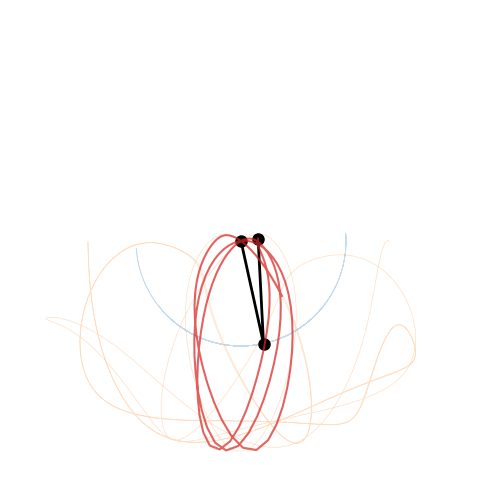

In [ ]:
## If you want an animated version you should use this. 

FPS = 30
stride = int(config.N/(FPS*config.T)) # in frames
n_frames = config.N #
trail_len = 150 # Number of finished frames... i.e. 5sec*30FPS = 150 frames. 

sl = slice(0, stride * n_frames, stride)
x0s_anim, x1s_anim = x0s[sl], x1s[sl]
y0s_anim, y1s_anim = y0s[sl], y1s[sl]

R = (l0 + l1) * 1.1
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-R, R) 
ax.set_ylim(-R, R)
ax.set_aspect('equal') 
ax.axis('off')

# background: full trajectories (light)
ax.plot(x0s, y0s, lw=0.5, alpha=0.25, color='C0', label='mass 1 (full)')
ax.plot(x1s, y1s, lw=0.5, alpha=0.25, color='C1', label='mass 2 (full)')

line,  = ax.plot([], [], 'o-', lw=2, color='black', mfc='black', ms=8)
trail, = ax.plot([], [], '-', lw=1.5, color='tab:red', alpha=0.7)

def init():
    line.set_data([], [])
    trail.set_data([], [])
    return line, trail

def update(i):
    line.set_data([0, x0s_anim[i], x1s_anim[i]], [0, y0s_anim[i], y1s_anim[i]])
    lo = max(0, i - trail_len)
    trail.set_data(x1s_anim[lo:i+1], y1s_anim[lo:i+1])
    return line, trail

ani = FuncAnimation(fig, update, frames=len(x0s_anim),
                    init_func=init, interval=20, blit=True)
ani.save("double_pendulum4.mp4", fps=FPS, dpi=200)
print('saved animation')
plt.show()
